In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Customer Churn.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
# replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [44]:
df["total charges"] = df["TotalCharges"].replace(" ", "0").astype("float")

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [46]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [47]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,total charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [48]:
df["customerID"].duplicated().sum()

np.int64(0)

In [49]:

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand.

def conv(value):
  if value ==  1:
           return "yes"
  else:
      return "no"

df['senior citizen'] = df['SeniorCitizen'].apply(conv)




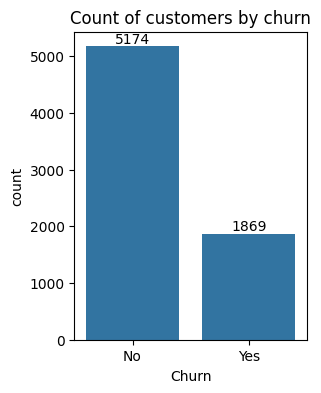

In [50]:
plt.figure(figsize=(3, 4))
ax = sns.countplot ( x = 'Churn', data=df)

ax.bar_label(ax.containers[0])
plt.title( "Count of customers by churn")
plt.show()

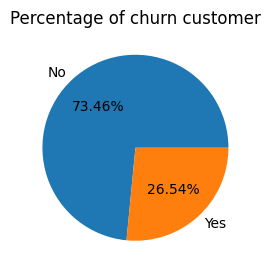

In [51]:
plt.figure(figsize=(3, 4))
gb = df.groupby("Churn").agg({'Churn': "count"})
plt.pie(gb['Churn'], labels = gb.index,autopct = "%1.2f%%")
plt.title( "Percentage of churn customer")
plt.show()


From the pie chart, we can conclude that 26.54% of our customers have churned out. Now, let's explore the reasons behind this churn.

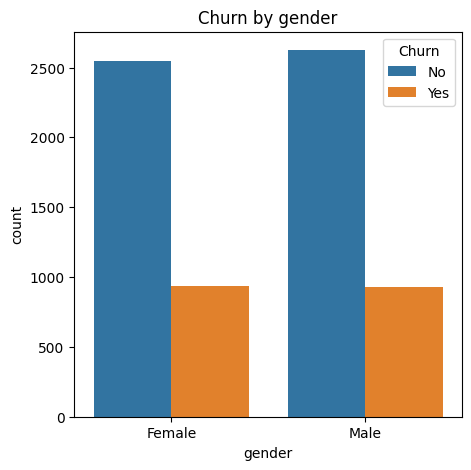

In [52]:
plt.figure(figsize=(5, 5))
sns.countplot( x="gender", data=df, hue= "Churn")
plt.title( "Churn by gender")
plt.show()

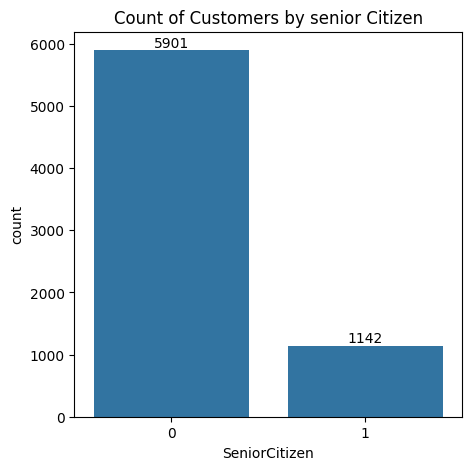

In [53]:
plt.figure(figsize=(5, 5));
ax = sns.countplot( x="SeniorCitizen", data=df)
ax.bar_label(ax.containers[0]);
plt.title( "Count of Customers by senior Citizen");
plt.show()

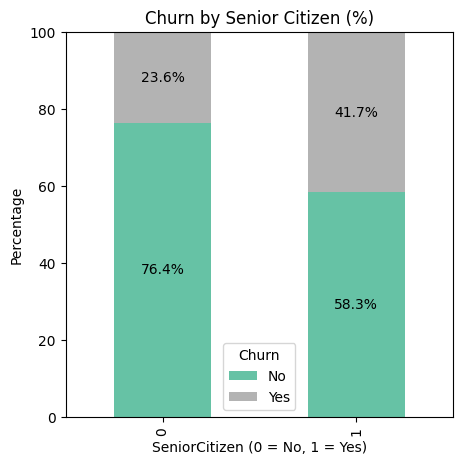

In [54]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])
ct_perc = ct.div(ct.sum(axis=1), axis=0) * 100
ax = ct_perc.plot(kind='bar', stacked=True, figsize=(5,5), colormap="Set2")


for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                ha='center', va='center', fontsize=10, color='black')

plt.title("Churn by Senior Citizen (%)")
plt.ylabel("Percentage")
plt.xlabel("SeniorCitizen (0 = No, 1 = Yes)")
plt.legend(title="Churn")
plt.ylim(0, 100)
plt.show()


From the plot, we can observe that a significantly higher percentage of senior citizens churn (41.7%) compared to non-senior citizens (23.6%).

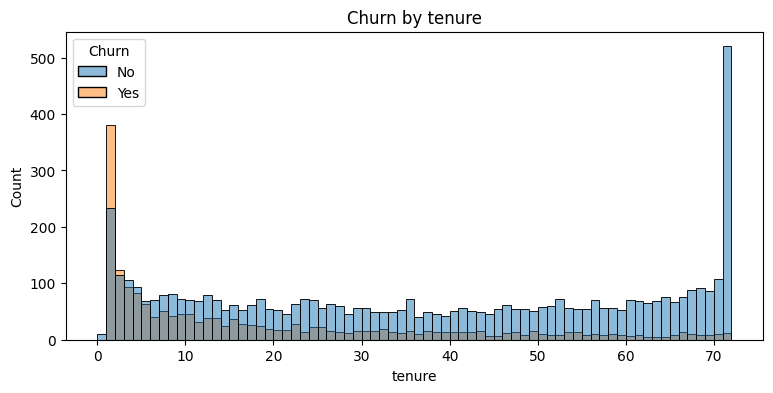

In [55]:
plt.figure(figsize=(9, 4));
sns.histplot(x="tenure", data=df,  bins = 72, hue="Churn");
plt.title( "Churn by tenure");
plt.show()

The histogram shows the distribution of churn by tenure. It appears that customers with shorter tenures are more likely to churn than those with longer tenures.

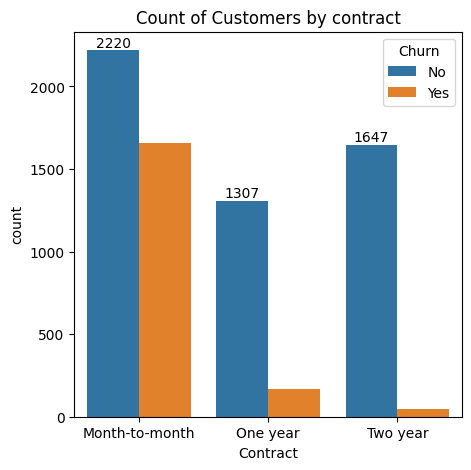

In [56]:
plt.figure(figsize=(5, 5));
ax = sns.countplot( x="Contract", data=df, hue= "Churn")
ax.bar_label(ax.containers[0]);
plt.title( "Count of Customers by contract");
plt.show()

The countplot shows the number of customers by contract type, separated by churn status. It highlights that customers with month-to-month contracts have a significantly higher churn rate compared to those with one-year or two-year contracts.

In [57]:
df.columns.values


array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'total charges', 'senior citizen'],
      dtype=object)

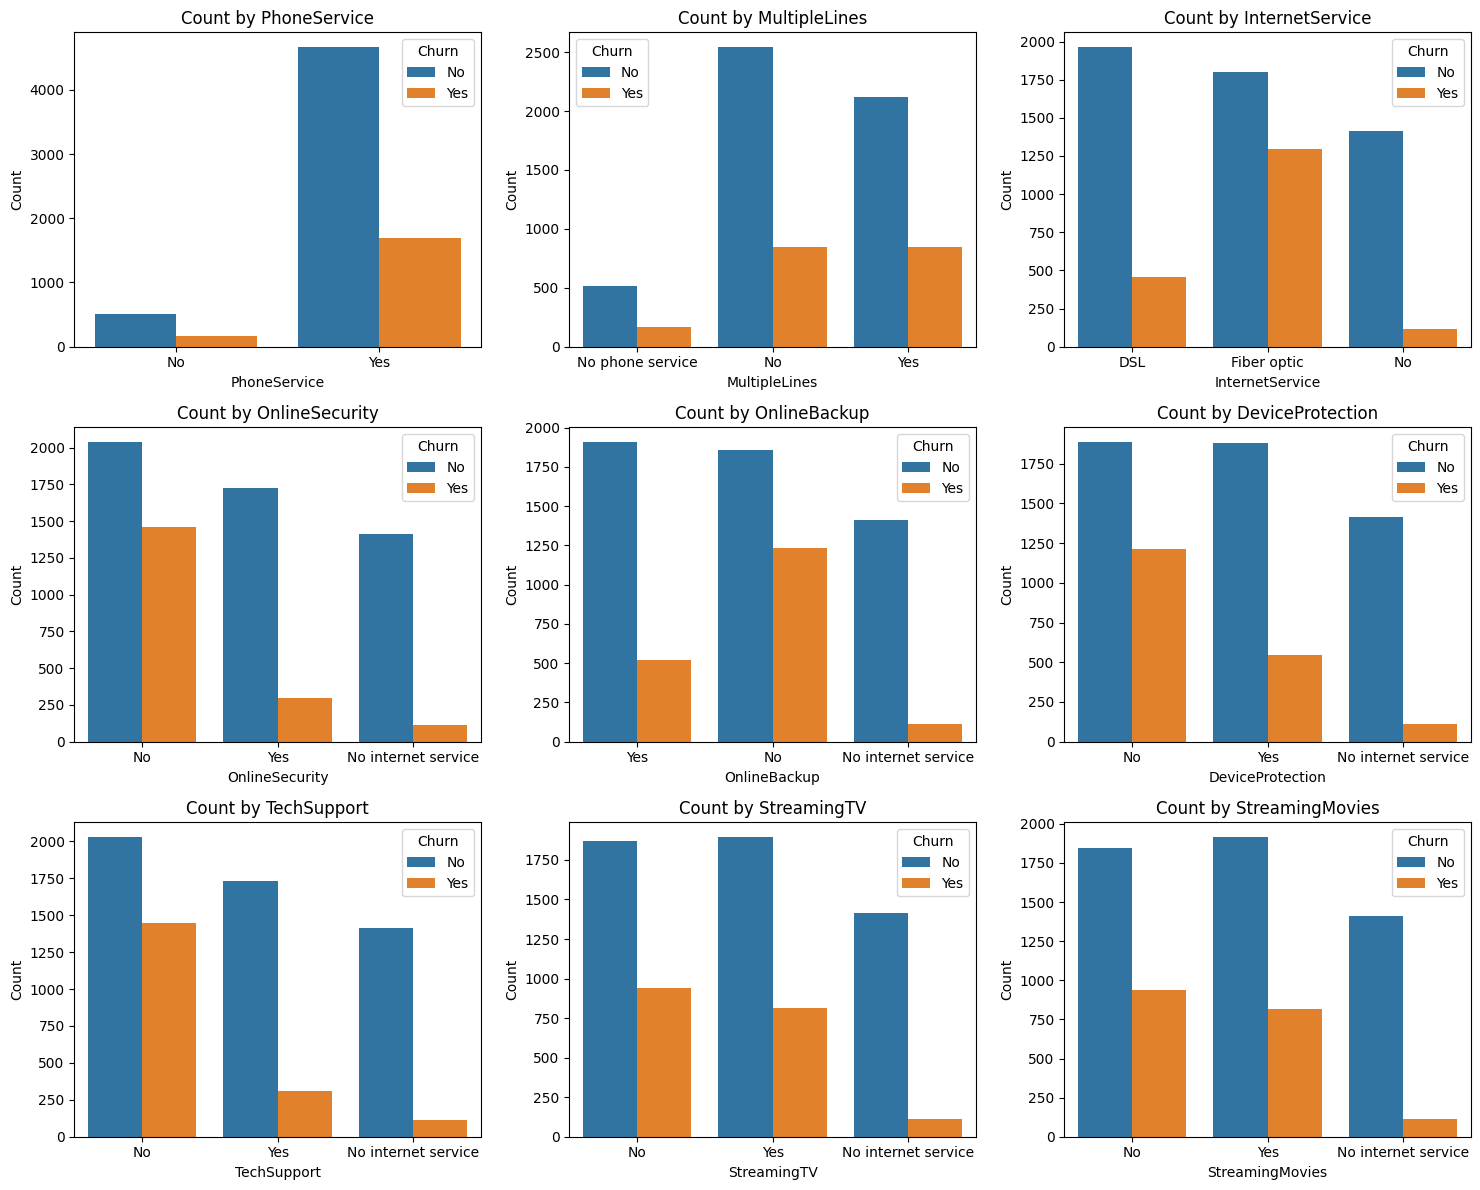

In [58]:


# List of categorical columns
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplots grid (3 rows × 3 cols = 9 plots)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # flatten 2D axes to 1D for easy iteration

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue="Churn", ax=axes[i])
    axes[i].set_title(f"Count by {col}")
    axes[i].set_ylabel("Count")

# Hide any empty subplot if cols < total grid
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


The charts illustrate customer churn across various services. Notably, customers without online security or tech support services exhibit higher churn rates. Conversely, those with these services, as well as device protection and online backup, tend to have lower churn.

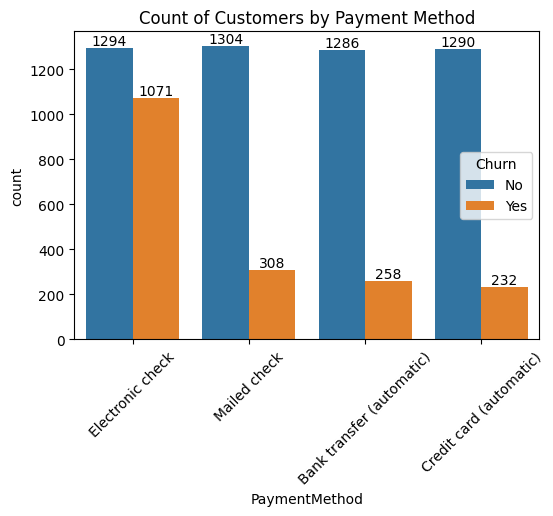

In [59]:
plt.figure(figsize=(6, 4));
ax = sns.countplot( x="PaymentMethod", data=df, hue= "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title( "Count of Customers by Payment Method");
plt.xticks(rotation=45)
plt.show()

The bar plot shows the count of customers by payment method, separated by churn status. It indicates that customers using electronic checks have the highest number of churned customers compared to other payment methods.